In [1]:
# Run this cell to set up packages for lecture.
from lec21_imports import *

# Lecture 21 – TVD, Hypothesis Testing, and Permutation Testing

## DSC 10, Spring 2026

### Agenda

- Total variation distance for comparing categorical distributions.
- Confidence intervals for hypothesis testing.
- Permutation testing.
    - Comparing two samples.

## Total variation distance for comparing categorical distributions

### Jury panels

Recall the jury panel selection process:

<center>$\substack{\text{eligible} \\ \text{population}}
\xrightarrow{\substack{\text{representative} \\ \text{sample}}} 
\substack{\text{jury} \\ \text{panel}}
\xrightarrow{\substack{\text{selection by} \\ \text{judge/attorneys}}} 
\substack{\text{actual} \\ \text{jury}}$</center>

Section 197 of California's Code of Civil Procedure says, 
> "All persons selected for jury service shall be selected at random, from a source or sources inclusive of a representative cross section of the population of the area served by the court."

### Racial and Ethnic Disparities in Alameda County Jury Pools

- The American Civil Liberties Union (ACLU) of Northern California [studied](https://www.aclunc.org/sites/default/files/racial_and_ethnic_disparities_in_alameda_county_jury_pools.pdf) the ethnic composition of jury panels in 11 felony trials in Alameda County between 2009 and 2010.

- 1453 people reported for jury duty in total (we will call them "panelists").

- The following DataFrame shows the distribution in ethnicities for both the eligible population and for the panelists who were studied.

In [2]:
jury = bpd.DataFrame().assign(
    Ethnicity=['Asian', 'Black', 'Latino', 'White', 'Other'],
    Eligible=[0.15, 0.18, 0.12, 0.54, 0.01],
    Panels=[0.26, 0.08, 0.08, 0.54, 0.04]
)
jury

,Ethnicity,Eligible,Panels
0,Asian,0.15,0.26
1,Black,0.18,0.08
2,Latino,0.12,0.08
3,White,0.54,0.54
4,Other,0.01,0.04


What do you notice? 👀

### Are the differences in representation meaningful?

- **Null Hypothesis:** Panelists were selected at random from the eligible population.

- **Alternative Hypothesis:** Panelists were _not_ selected at random from the eligible population.

- Observation: 1453 panelists and the distribution of their ethnicities.

- Test statistic: ???
    - How do we deal with multiple categories?

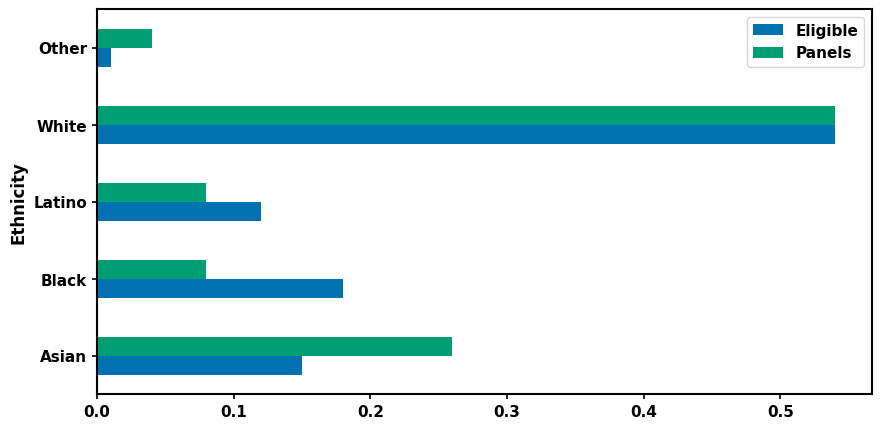

In [3]:
jury.plot(kind='barh', x='Ethnicity', figsize=(10, 5));

### The distance between two distributions

- Panelists are categorized into one of 5 ethnicities. In other words, ethnicity is a **categorical** variable.

- To see whether the the distribution of ethnicities for the panelists is similar to that of the eligible population, we have to measure the distance between two categorical distributions.
    - We've done this for distributions with just two categories – heads and tails, for instance – but not when there are more than two categories.

### The distance between two distributions

- Let's start by considering the difference in proportions for each category.

In [4]:
with_diffs = jury.assign(Difference=(jury.get('Panels') - jury.get('Eligible')))
with_diffs

,Ethnicity,Eligible,Panels,Difference
0,Asian,0.15,0.26,0.11
1,Black,0.18,0.08,-0.10
2,Latino,0.12,0.08,-0.04
3,White,0.54,0.54,0.00
4,Other,0.01,0.04,0.03


- Note that if we sum these differences, the result is 0 (you'll see the proof in DSC 40A).
- To avoid cancellation of positive and negative differences, we can take the absolute value of these differences.

In [5]:
with_abs_diffs = with_diffs.assign(AbsoluteDifference=np.abs(with_diffs.get('Difference')))
with_abs_diffs

,Ethnicity,Eligible,Panels,Difference,AbsoluteDifference
0,Asian,0.15,0.26,0.11,0.11
1,Black,0.18,0.08,-0.10,0.10
2,Latino,0.12,0.08,-0.04,0.04
3,White,0.54,0.54,0.00,0.00
4,Other,0.01,0.04,0.03,0.03


### Statistic: Total Variation Distance

The **Total Variation Distance (TVD)** of two categorical distributions is **the sum of the absolute differences of their proportions, all divided by 2**.

- We divide by 2 so that, for example, the distribution [0.51, 0.49] is 0.01 away from [0.50, 0.50].

- It would also be valid not to divide by 2. We just wouldn't call that statistic TVD anymore.

In [6]:
with_abs_diffs

,Ethnicity,Eligible,Panels,Difference,AbsoluteDifference
0,Asian,0.15,0.26,0.11,0.11
1,Black,0.18,0.08,-0.10,0.10
2,Latino,0.12,0.08,-0.04,0.04
3,White,0.54,0.54,0.00,0.00
4,Other,0.01,0.04,0.03,0.03


In [7]:
with_abs_diffs.get('AbsoluteDifference').sum() / 2

0.14

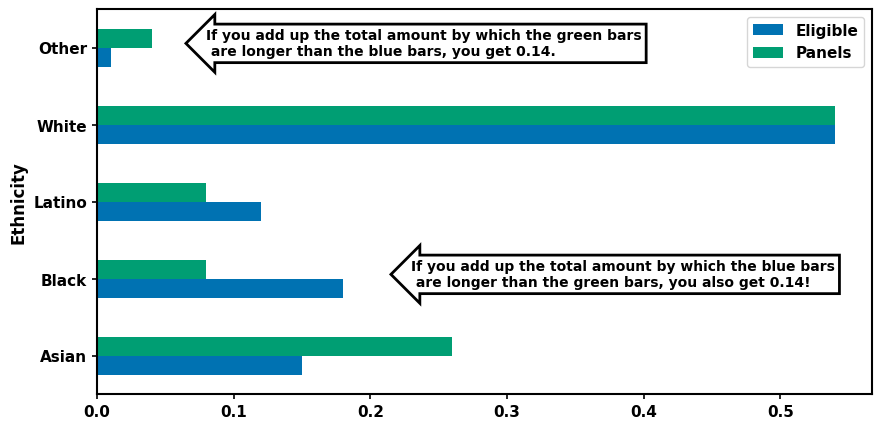

In [8]:
def total_variation_distance(dist1, dist2):
    '''Computes the TVD between two categorical distributions, 
       assuming the categories appear in the same order.'''
    return np.abs((dist1 - dist2)).sum() / 2

jury.plot(kind='barh', x='Ethnicity', figsize=(10, 5))
plt.annotate('If you add up the total amount by which the green bars\n are longer than the blue bars, you get 0.14.', (0.08, 3.9), bbox=dict(boxstyle="larrow,pad=0.3", fc='white', ec="black", lw=2));
plt.annotate('If you add up the total amount by which the blue bars\n are longer than the green bars, you also get 0.14!', (0.23, 0.9), bbox=dict(boxstyle="larrow,pad=0.3", fc='white', ec="black", lw=2));

- TVD quantifies the **total overrepresentation** across all categories. 
    - Equivalently, it also quantifies total underrepresentation across all categories.

### Concept Check ✅ – Answer at [cc.dsc10.com](http://cc.dsc10.com) 

What is the TVD between the distributions of class standing in DSC 10 and DSC 40A?

| **Class Standing** | **DSC 10** | **DSC 40A** |
| --- | --- | --- |
| Freshman | 0.45 | 0.15 |
| Sophomore | 0.35 | 0.35 |
| Junior | 0.15 | 0.35 |
| Senior+ | 0.05 | 0.15 |

- A. 0.2
- B. 0.3
- C. 0.5
- D. 0.6
- E. None of the above

### Simulate drawing jury panels

- Model: Panels are drawn at from the eligible population.

- Statistic: TVD between the random panel's ethnicity distribution and the eligible population's ethnicity distribution.

- Repeat many times to generate many TVDs, and see where the TVD of the observed panelists lies.

### The simulation

In [9]:
eligible = jury.get('Eligible')
sample_distribution = np.random.multinomial(1453, eligible) / 1453 
sample_distribution

array([0.15, 0.18, 0.11, 0.56, 0.01])

In [10]:
total_variation_distance(sample_distribution, eligible)

0.017467309015829293

_Note_: `np.random.multinomial` creates samples drawn with replacement, even though real jury panels would be drawn without replacement. However, when the sample size (1453) is small relative to the population (number of people in Alameda County), the resulting distributions will be roughly the same whether we sample with or without replacement.

### Repeating the experiment

In [11]:
tvds = np.array([])
repetitions = 10000
for i in np.arange(repetitions):
    sample_distribution = np.random.multinomial(1453, eligible) / 1453
    new_tvd = total_variation_distance(sample_distribution, eligible)
    tvds = np.append(tvds, new_tvd)

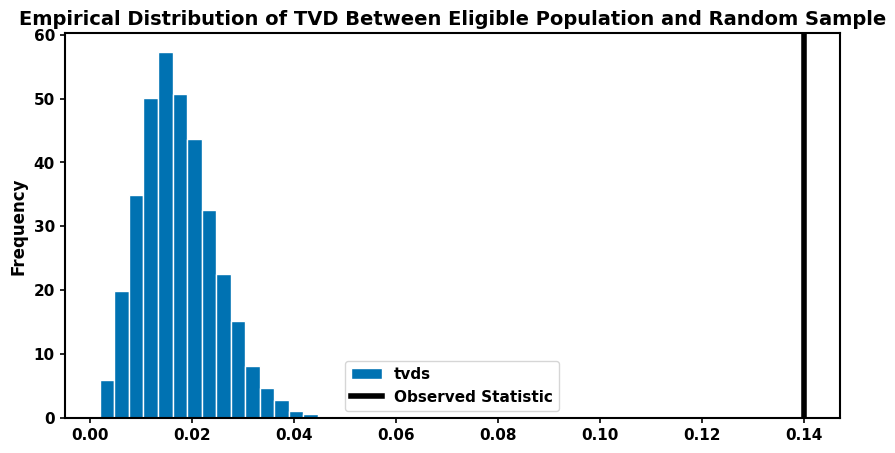

In [12]:
observed_tvd = total_variation_distance(jury.get('Panels'), eligible)

bpd.DataFrame().assign(tvds=tvds).plot(kind='hist', density=True, bins=20, ec='w', figsize=(10, 5),
                                      title='Empirical Distribution of TVD Between Eligible Population and Random Sample')
plt.axvline(observed_tvd, color='black', linewidth=4, label='Observed Statistic')
plt.legend();

### Calculating the p-value

In [13]:
np.count_nonzero(tvds >= observed_tvd) / repetitions

0.0

- Random samples from the eligible population are typically **much more similar** to the eligible population than our observed data. 
- We see this in the empirical distribution, which consists of **small TVDs** (much smaller than our observed TVD).

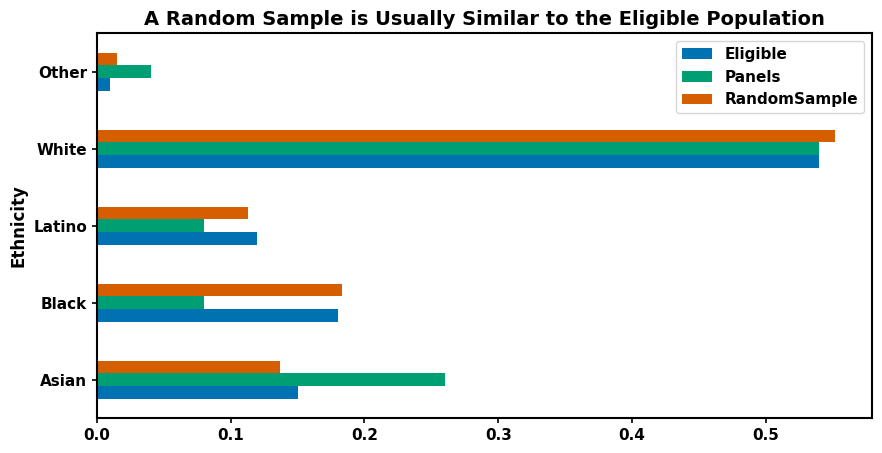

In [14]:
jury.assign(RandomSample=sample_distribution).plot(kind='barh', x='Ethnicity', figsize=(10, 5),
                                                   title = "A Random Sample is Usually Similar to the Eligible Population");

### Are the jury panels representative?

- Likely not! The distributions of ethnicities in our random samples are not like the distribution of ethnicities in our observed panelists.

- This doesn't say *why* the distributions are different!
    - Juries are drawn from voter registration lists and DMV records. Certain populations are less likely to be registered to vote or have a driver's license due to historical biases.
    - The county rarely enacts penalties for those who don't appear for jury duty; certain populations are less likely to be able to miss work to appear for jury duty.
    - See the [press release](https://www.aclu.org/press-releases/new-study-finds-serious-racial-and-ethnic-disparities-alameda-county-jury-pools) for a summary of the ACLU's conclusions and recommendations.

## Confidence intervals for hypothesis testing

### Hypothesis testing, another way

- It turns out that we can use confidence intervals for hypothesis testing, when our hypotheses take a certain form:
    - **Null Hypothesis**: The population parameter is equal to some value, $x$.
    - **Alternative Hypothesis**: The population parameter is not equal to $x$.

- We'll use the following strategy.
    1. Choose a p-value cutoff of p%.
    2. Construct a (100-p)% confidence interval for the population parameter.
    3. Interpret the results:
        - If $x$ is not in the confidence interval, we reject the null hypothesis.
        - If $x$ is in the confidence interval, we fail to reject the null hypothesis (since our results are consistent with the null).

### Example: Body temperature 🌡

It is widely accepted that the mean human body temperature is 98.6 ºF (or 37 ºC). We have a dataset of body temperatures, and want to see if our dataset is consistent with that belief.

In [15]:
temperatures = bpd.read_csv('data/temp.csv')
temperatures

,temperature
0,96.3
1,96.7
2,96.9
...,...
127,99.9
128,100.0
129,100.8


In [16]:
temperatures.get('temperature').describe()

count    130.00
mean      98.25
std        0.73
          ...  
50%       98.30
75%       98.70
max      100.80
Name: temperature, Length: 8, dtype: float64

### Setting up a hypothesis test

- We will test the following hypotheses at the standard p = 0.05 significance level.
    - **Null Hypothesis**: The mean body temperature of all people is 98.6 ºF.
    - **Alternative Hypothesis**: The mean body temperature of all people is not 98.6 ºF.

- The mean body temperature of all people is a population parameter. We can estimate this parameter with a confidence interval. 

- Since we are estimating a population **mean**, there are two possible approaches to creating a confidence interval.
    1. Bootstrapping.
    2. Using the Central Limit Theorem.

### Bootstrap-based confidence interval for mean body temperature

We are given a sample of 130 body temperatures.  We can bootstrap this original sample to calculate many resample means, then use percentiles to find a 95% confidence interval for the population mean. 

In [17]:
resample_means = np.array([])
for i in np.arange(10000):
    resample = temperatures.sample(130, replace=True)
    resample_means = np.append(resample_means, resample.get('temperature').mean())
resample_means

array([98.26, 98.23, 98.3 , ..., 98.33, 98.32, 98.2 ])

In [18]:
left_boot = np.percentile(resample_means, 2.5)
right_boot = np.percentile(resample_means, 97.5)

# 95% bootstrap-based confidence interval for the mean body temperature of all people:
[left_boot, right_boot]

[98.12615384615385, 98.3746153846154]

### CLT-based confidence interval for mean body temperature

 - We can alternatively use the CLT to calculate a 95% confidence interval for the population mean:

$$
\left[
\text{sample mean} - 2\cdot \frac{\text{sample SD}}{\sqrt{\text{sample size}}}, \
\text{sample mean} + 2\cdot \frac{\text{sample SD}}{\sqrt{\text{sample size}}}
\right]
$$

- Thanks to the CLT, we have an understanding of the distribution of the sample mean, even though we don't know anything about the distribution of body temperatures. 

- We **don't need to assume that body temperatures are normally distributed** to use the CLT!

In [19]:
sample_mean_mean = temperatures.get('temperature').mean()
sample_mean_mean

98.24923076923078

In [20]:
sample_mean_sd = np.std(temperatures.get('temperature')) / np.sqrt(temperatures.shape[0])
sample_mean_sd

0.06405661469519337

In [21]:
left_normal = sample_mean_mean - 2 * sample_mean_sd
right_normal = sample_mean_mean + 2 * sample_mean_sd

# 95% CLT-based confidence interval for the mean body temperature of all people:
[left_normal, right_normal]

[98.12111753984038, 98.37734399862117]

### Comparing intervals and interpreting the results

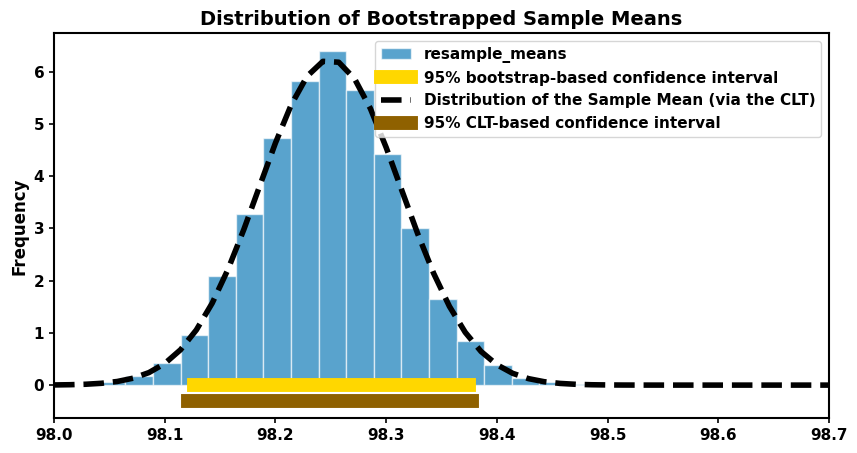

In [22]:
def normal_curve(x, mu=0, sigma=1):
    return (1 / np.sqrt(2 * np.pi * sigma ** 2)) * np.exp((- (x - mu) ** 2) / (2 * sigma ** 2))

bpd.DataFrame().assign(resample_means=resample_means).plot(kind='hist', y='resample_means', alpha=0.65, bins=20, density=True, ec='w', figsize=(10, 5), title='Distribution of Bootstrapped Sample Means');
plt.plot([left_boot, right_boot], [0, 0], color='gold', linewidth=10, label='95% bootstrap-based confidence interval');

norm_x = np.linspace(98, 98.7)
norm_y = normal_curve(norm_x, mu=sample_mean_mean, sigma=sample_mean_sd)
plt.plot(norm_x, norm_y, color='black', linestyle='--', linewidth=4, label='Distribution of the Sample Mean (via the CLT)')
plt.xlim(98, 98.7)
plt.plot([left_normal, right_normal], [-0.3, -0.3], color='#8f6100', linewidth=10, label='95% CLT-based confidence interval')


plt.legend();

- Is 98.6 ºF in the interval we found (with either method)? No. ❌

- Therefore, we **reject the null hypothesis** at the standard significance level of 0.05. It doesn't look like the mean body temperature of all people is 98.6 ºF.

### What happened?

- 98.6 ºF is due to Carl Reinhold August Wunderlich, a 19th century physician, who conducted a study when thermometers were new.
    - [This LA Times article](https://www.latimes.com/archives/la-xpm-2007-nov-26-he-esoterica26-story.html) states that it's likely that Wunderlich's thermometer was miscalibrated.

- [A recent article by the Yale School of Medicine](https://www.yalemedicine.org/news/temperature-checks-covid) states that the average body temperature has declined  over the last 150 years by 1.5 ºF, and that body temperature depends on the time of day, age, and sex, among other things.

## Comparing two samples

### Reflection

So far, we've used hypothesis tests to answer questions of the form:

> I have a population distribution, and I have **one sample**. Does this sample look like it was drawn from the population?

Next, we want to consider questions of the form:

> I have **two samples**, but no information about any population distributions. Do these samples look like they were drawn from the same population?

We can't use hypothesis testing to answer such questions yet, because all of our hypothesis tests have relied on **knowing the population distribution**. But what if you don't know the population distribution?

- Are the distributions of weight for babies 👶 born to smoking mothers vs. non-smoking mothers different?

- Are the distributions of pressure drops for footballs 🏈 from two different teams different?

These questions are answered through **A/B testing**. Permutation testing is **one type of** A/B testing.

### 2008 Obama Campaign

<center><img src='images/obama.png' width=600></center>

- In 2008, the Obama campaign tested several different versions of a pop-up box on their website. Each visitor to the site would view a random version of the site, with different buttons and images.

- For each version, they recorded the number of people who signed up to be a donor.

- Read more at [this blog post](https://blog.optimizely.com/2010/11/29/how-obama-raised-60-million-by-running-a-simple-experiment/).

### Button choices

- Here are the four different buttons they used.

<center><img src='images/buttons.png' width=300>

- Which one do you think would lead to the most signups?

### The winner

<center><img src='images/winner.png' width=600>

It is estimated that this combination of image and button brought in an **additional 60 million dollars** in donations versus the original version of the site. 

## Example: Smoking and birth weight 👶

### Smoking and birth weight

- **Question:** Is there a significant difference in the weights of babies born to mothers who smoked vs. babies born to mothers who didn't smoke?

- To approach this question, we'll look at data from a research study.
    - Each row corresponds to a baby.
    - There are two groups of babies: those whose mothers smoked ("smokers' babies"), and those whose mothers didn't smoke ("non-smokers' babies").

In [23]:
babies = bpd.read_csv('data/baby.csv').get(['Maternal Smoker', 'Birth Weight'])
babies

,Maternal Smoker,Birth Weight
0,False,120
1,False,113
2,True,128
...,...,...
1171,True,130
1172,False,125
1173,False,117


Note: The `'Birth Weight'` column is measured in ounces; 100 ounces = 6.25 pounds.

### Visualizing the distribution of each group

In [24]:
smokers = babies[babies.get('Maternal Smoker')]
non_smokers = babies[babies.get('Maternal Smoker') == False]

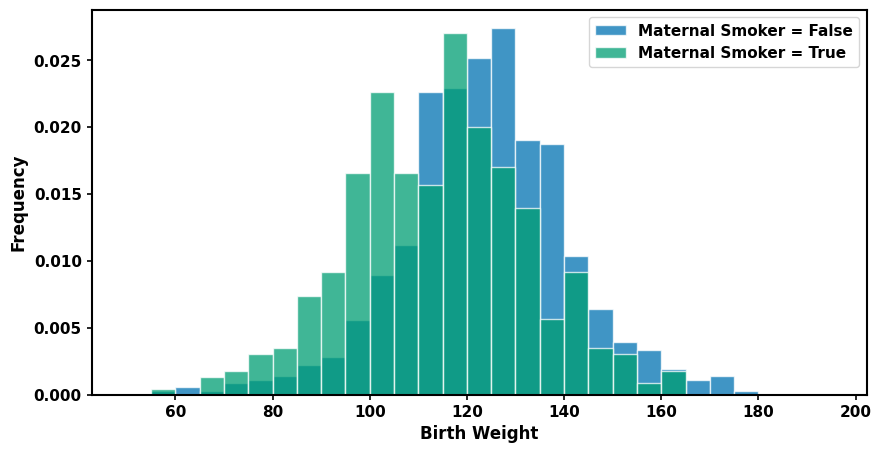

In [25]:
fig, ax = plt.subplots()
baby_bins = np.arange(50, 200, 5)
non_smokers.plot(kind='hist', density=True, ax=ax, alpha=0.75, bins=baby_bins, ec='w', figsize=(10, 5))
smokers.plot(kind='hist', density=True, ax=ax, alpha=0.75, bins=baby_bins, ec='w')
plt.legend(['Maternal Smoker = False', 'Maternal Smoker = True'])
plt.xlabel('Birth Weight');

What do you notice? 👀

### The question

- It appears that, **in our sample**, smokers' babies typically have lower birth weights than non-smokers' babies.

- Does the difference we see reflect a real difference in the population?

- Or is this pattern just due to random chance?

- Let's run a hypothesis test!

### Setting up a hypothesis test

- **Null Hypothesis**: In the population, birth weights of smokers' babies and non-smokers' babies have the same distribution, and the observed differences in our samples are due to random chance.

- **Alternative Hypothesis**: In the population, smokers' babies have lower birth weights than non-smokers' babies, on average. The observed differences in our samples cannot be explained by random chance alone.

- Now that we have our hypotheses, we need to devise a test statistic that we can simulate under the null hypothesis.

### Discussion Question

We recently introduced the total variation distance (TVD) as a test statistic. Why **can't** we use the TVD as our test statistic in this hypothesis test?

### Test statistic: the difference in group means

The test statistic we'll use is the difference in group means:

$$\substack{\text{mean birth weight of} \\ \text{non-smokers' babies}} \hspace{0.5in} - \hspace{0.5in} \substack{\text{mean birth weight of} \\ \text{smokers' babies}}$$

Note that **large values of this test statistic favor the alternative hypothesis**.

Let's compute the observed statistic:

In [26]:
means_df = babies.groupby('Maternal Smoker').mean()
means_df

,Birth Weight
Maternal Smoker,
False,123.09
True,113.82


In [27]:
# The difference between the mean birth weight for non-smokers and smokers.
means = means_df.get('Birth Weight')
observed_difference = means.loc[False] - means.loc[True]
observed_difference

9.266142572024918

### Setting up a hypothesis test

- **Null Hypothesis**: In the population, birth weights of smokers' babies and non-smokers' babies have the same distribution, and the observed differences in our samples are due to random chance.

- **Alternative Hypothesis**: In the population, smokers' babies have lower birth weights than non-smokers' babies, on average. The observed differences in our samples cannot be explained by random chance alone.

- Test statistic: Difference in mean birth weight of non-smokers' babies and smokers' babies.

### Generating new samples under the null hypothesis

- Under the null hypothesis, both groups are sampled from the same population distribution.

- We need to sample from that population distribution to create an empirical distribution of test statistics under the assumptions of the null hypothesis.

- 🚨 **Issue**: We don't have the population distribution, so we can't draw samples from it!

### Constructing a population

- **Idea**: We can construct a "population" by combining both of our samples. Then, to create two random samples from it, we just separate (or split) the population into two random groups.

- We can do this because, under the null hypothesis, the mother's smoking status has no impact on the baby's birth weight, so all baby weights come from the same population.

In [28]:
show_permutation_testing_intro()

## Summary, next time

### Summary

- The total variation distance is a test statistic that measures the difference between two categorical distributions.
    - Note: the TVD is not used for permutation tests!
- Before today, we used hypothesis tests to determine if **one sample** came from a known population distribution.
- Permutation tests help us determine if **two samples** came from the same population. We can answers questions like:
    - "Do smokers' babies and non-smokers babies' weigh the same?"
    - More generally: are these things like those things?

### A/B testing

- Permutation tests are one way to perform A/B tests.
- These are both also hypothesis tests.
- An A/B test aims to determine if two samples are from the same population (the name comes from giving names to the samples – sample A and sample B).
- We implemented A/B tests by using permutations. Outside of this class, permutation tests can be used for other purposes, and A/B tests can be done without permutations.
- **For us, they mean the same thing, so if you see A/B test anywhere in the class, it refers to a permutation test.**

### Next time

Two full examples of permutation tests.